In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature







from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)

In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

In [4]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', None), lat = slice(25, -15)).sel(plev = 50000)

In [5]:
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])

clim = t500.sel(time = slice('1991', '2020')).ocean_mean.groupby('time.month').mean()
t500['anom'] = t500.ocean_mean.groupby('time.month') - clim


#convert
t500 = convert_to_potential_temperature(t500, p = 500)

t500 = t500.rolling(time = 3, center = True, min_periods = 1).mean()

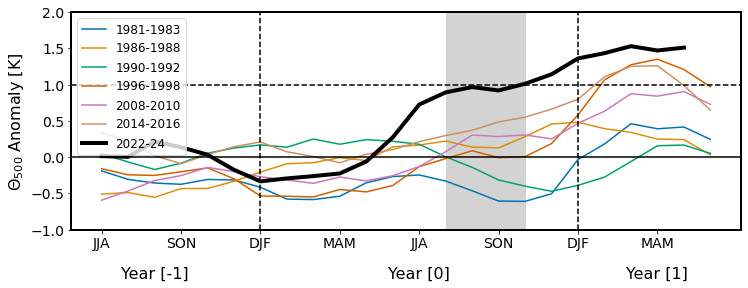

In [6]:

# Define event years
c_years = [1982, 1987, 1991, 1997, 2009,  2015]

# Get a nice color palette (e.g., Set2, colorblind, Paired)
colors = sns.color_palette("colorblind", len(c_years))  # Try "colorblind", "Set1", or "tab10"

fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharey=True)

# Loop through historical years with better colors
for i, c in enumerate(c_years):
    ds_sel = t500.sel(time=slice(f"{c-1}-07", f"{c+1}-06"))
    ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.anom, label=f"{c-1}-{c+1}", color=colors[i])

# Recent period in black, thicker line
ds_sel = t500.sel(time=slice("2022-07", "2024-06"))
ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.anom, label="2022-24", color="k", linewidth=4)



#graphical stuff
# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months



ax.axhline(0, c = 'k')
ax.axhline(1, c = 'k', linestyle = '--')
ax.axhline(-1, c = 'k', linestyle = '--')
ax.axhline(2, c = 'k', linestyle = ':')
ax.axhline(-2, c = 'k', linestyle = ':')

ax.fill_between(x = [13,16], y1 = 3, y2 = -3, color = 'lightgrey' )


ax.set_ylabel(r'$\Theta_{500}$ Anomaly [K]', fontsize = 16, fontweight = 'normal')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize =16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(-1, 2)


ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

    # Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

    # Second row: Manually add every 8th label slightly lower
for i in [2,12,21]:
    ax.text(i, -1.5, f"Year [{i//10 -1}]", ha="center", va="top", fontsize=16, color="black",
            fontweight ='normal')




ax.legend(fontsize= 12, loc = 'upper left')
#ax.set_title('ONI Evolution during El-Nino', fontweight = 'normal');

# Add title and format ticks
fig.savefig('output/Fig4a.svg', dpi = 600, bbox_inches='tight')


## PWS

In [7]:

from statsmodels.nonparametric.smoothers_lowess import lowess

def detrend_yearly_loess_full(s, frac=0.6):
    """
    Detrend a full time series using LOESS smoothing.
    
    Parameters:
        s (xr.DataArray): Input data with a 'year' coordinate.
        frac (float): Fraction of data used for LOESS smoothing (controls smoothness).
    
    Returns:
        xr.DataArray: Detrended data array.
    """
    # Extract years and values
    years = s.year.values
    values = s.values

    # Apply LOESS smoothing to the full dataset
    loess_fit = lowess(values, years, frac=frac, return_sorted=False)

    

    # Detrend the data
    detrended_values = values - loess_fit

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


# T500

In [8]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', '2023'), lat = slice(25, -15)).sel(plev = 50000)
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])


In [9]:
#convert to potential temperature
t500 = convert_to_potential_temperature(t500, 500)

In [10]:
#ASO season
t500_aso = t500.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

clim = t500_aso.sel(year = slice('1991', '2020')).ocean_mean.mean('year')

#ASO anom
t500_aso['ocean_anom'] = t500_aso.ocean_mean - clim

In [11]:
t500_aso['det'] = detrend_yearly_loess_full(t500_aso.ocean_anom)

###  Ocean Mask

In [12]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifc
#ocean_mask = masks.seamask ==1

## w500

In [13]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(25, -15), time= slice('1979', None))

w500 = w500.where(ocean_mask)



#convert to hpa/day
w500 = w500*(24*3600/100)

In [14]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))
#ocean_mask = ~sst.isel(time = 1).sst.isnull()
sst = sst.where(ocean_mask)

In [15]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [16]:
# compute nino34 for aso 
nino34 = sst_aso.sel(lat = slice(15, -15), lon = slice(190, 240))
nino34 = nino34 - nino34.sel(year = slice('1991', '2020')).mean('year')
nino34 = nino34.weighted(np.cos(np.deg2rad(nino34.lat))).mean(['lat', 'lon'])


## TP

In [17]:
fp = '/data/jmex/NOAA/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice('1979','2023'))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})

#tp aso only 

tp_aso = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [18]:
#interp sst to match gpcp
sst_aso = sst_aso.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')

#second ocean_mask, on the GPCP grid
#make ocean mask
ocean_mask2 = ~sst_aso.isel(year = 1).sst.isnull()


#take t for ocean mask only: 
tp_aso = tp_aso.where(ocean_mask2)

weights = np.cos(np.deg2rad(tp.lat))
tp_aso['ocean_mean'] = tp_aso.tp.weighted(weights).mean(['lat', 'lon'])

## PWS

In [19]:
pws_aso = xr.zeros_like(sst_aso)
pws_aso = pws_aso.rename({'sst': 'pws'})

In [20]:
pws_aso['pws'] = sst_aso.sst * tp_aso.tp/tp_aso.ocean_mean 

pws_aso['pws_mean'] = pws_aso.pws.weighted(weights).mean(['lat', 'lon'])
#subtract mean
pws_aso['pws_mean'] = pws_aso['pws_mean']-pws_aso.pws_mean.mean()

In [21]:
pws_aso['pws_detrended'] = detrend_yearly_loess_full(pws_aso.pws_mean)

### t2m


In [22]:
#import t2m
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp).sel(time = slice('1979', '2023'))
weights = np.cos(np.deg2rad(t2m.lat))


In [23]:
t2m_aso = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [24]:
t2m_aso = t2m_aso.weighted(weights).mean(['lat', 'lon'])
t2m_aso['t2m_detrended'] = detrend_yearly_loess_full(t2m_aso.t2m)

## Regression

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

def plot_with_regression(ax, x, y, x_label, y_label, years, highlight_years=[], volc_years=[]):
    x = np.asarray(x)
    y = np.asarray(y)
    years = np.asarray(years)
    
    # Fit regression
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, y_pred)

    # Base scatter
    ax.scatter(x, y, c='lightgrey', s=40, label='_base')

    # Color palette for highlighted years
    color_palette = sns.color_palette("colorblind", len(highlight_years))
    year_color_map = dict(zip(highlight_years, color_palette))

    # Plot highlighted years and their previous years
    for i, yr in enumerate(highlight_years):
        idx = np.where(years == yr)[0][0]
        ax.scatter(x[idx], y[idx], color=year_color_map[yr], s=80, label=str(yr), zorder=3)

        # Mark the previous year
        prev_year = yr - 1
        if prev_year in years:
            prev_idx = np.where(years == prev_year)[0][0]
            ax.scatter(x[prev_idx], y[prev_idx], 
                       facecolor='lightgrey', edgecolor=year_color_map[yr], 
                       linewidth=2, s=60, zorder=2)

    # Highlight 2023
    if 2023 in years:
        idx_2023 = np.where(years == 2023)[0][0]
        idx_2022 = np.where(years == 2022)[0][0]

        # Plot 2023
        ax.scatter(x[idx_2023], y[idx_2023], c='black', s=80, label='2023', zorder=4)

        # Plot 2022
        ax.scatter(x[idx_2022], y[idx_2022], facecolor='lightgrey', edgecolor='black',
                   linewidth=2, s=60, label='2022/Year [-1]', zorder=4)

        # Draw arrow from 2022 to 2023
        ax.annotate(
            '',
            xy=(x[idx_2023], y[idx_2023]),
            xytext=(x[idx_2022], y[idx_2022]),
            arrowprops=dict(
                arrowstyle='->,head_length=2,head_width=1',  # smaller head
                linestyle='solid',#(0, (1, 5)),  
                color='black',
                lw=1.2  # slightly thinner
            ),
            zorder=3
        )


    # Volcanic years (black x)
    for j, volc_year in enumerate(volc_years):
        if volc_year in years:
            idx_volc = np.where(years == volc_year)[0][0]
            ax.scatter(x[idx_volc], y[idx_volc], c='black', s=100, marker='x', linewidths=2.0,
                       label='Volcanic' if j == 0 else None, zorder=1)

    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', label=f'$R^2 = {r2:.2f}$')

    # Zero lines
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)

    # Aesthetic cleanup
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Labels
    ax.set_xlabel(x_label, fontsize=20)
    ax.set_ylabel(y_label, fontsize=20)
    ax.tick_params(labelsize=14)
    ax.legend()

    print(r2)
    return y - y_pred  # residuals


0.6728025455178688


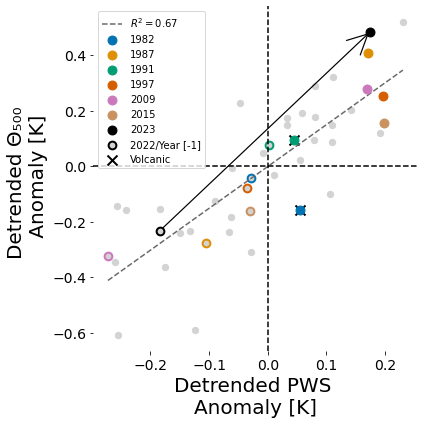

In [26]:
highlight_years = [1982, 1987, 1991, 1997, 2009, 2015]
volcanic_years = [1982, 1991]

fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=pws_aso.pws_detrended.values,
    y=t500_aso.det,
    x_label='Detrended PWS \nAnomaly [K]',
    y_label = 'Detrended Θ₅₀₀ \n Anomaly [K]',
    years=pws_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()
fig.savefig('output/Fig4b.svg', dpi = 600, bbox_inches='tight')



# Residuals

In [27]:
#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst_full = decode_time(fp).sel(lat = slice(90,-90), time = slice('1979', '2023'))


sst_full_aso = sst_full.where(sst_full.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [34]:
from scipy.stats import pearsonr

# Assuming residuals and sst_full_aso.sst are already defined
def calc_corr_and_pval(residuals, sst, dim='year'):
    def corr_and_pval(x, y):
        mask = ~np.isnan(x) & ~np.isnan(y)  # Handle NaNs
        if mask.sum() < 2:  # Not enough data points
            return np.nan, np.nan
        r, p = pearsonr(x[mask], y[mask])
        return r, p
    
    return xr.apply_ufunc(
        corr_and_pval, 
        residuals, 
        sst,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

# Calculate correlation and p-values
corr, pval = calc_corr_and_pval(residuals, sst_full_aso.sst)


corr.to_netcdf("output/data/corr.nc")
pval.to_netcdf("output/data/pval.nc")




###  Ocean Mask

In [30]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-90,90))
ocean_mask = masks.seamask # mask for all contintnets

/tmp/ipykernel_2756458/1786221156.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


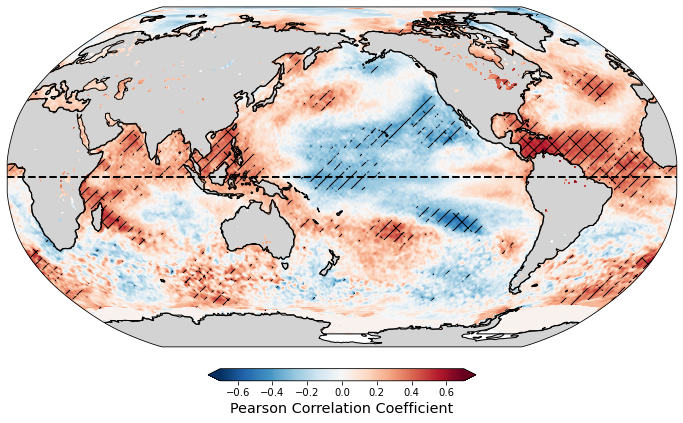

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot correlation using pcolormesh
cbar = ax.pcolormesh(corr.lon, corr.lat, corr, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin=-.7, vmax=.7)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson Correlation Coefficient')

# Add hatching for p < 0.05
sig_mask_005 = pval < 0.05
ax.contourf(corr.lon, corr.lat, sig_mask_005, levels=[0.5, 1.5],
            hatches=['//'], colors='none', transform=ccrs.PlateCarree())

# Add hatching for p < 0.01
sig_mask_001 = pval < 0.01
ax.contourf(corr.lon, corr.lat, sig_mask_001, levels=[0.5, 1.5],
            hatches=['\\'], colors='none', transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()
fig.savefig('output/Fig4c.pdf', bbox_inches='tight')



In [32]:
corr

<xarray.DataArray 'sst' (lat: 721, lon: 1440)>
array([[-0.03391771, -0.03391771, -0.03391771, ..., -0.03391771,
        -0.03391771, -0.03391771],
       [ 0.03017897, -0.1103392 , -0.01371159, ...,  0.03017897,
         0.03017897,  0.03017897],
       [ 0.03017897, -0.00271219, -0.00271219, ..., -0.01332353,
         0.03017897, -0.00271219],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
  * lon      (lon) float64 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float64 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75 -90.0

/tmp/ipykernel_2663040/1514204927.py:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


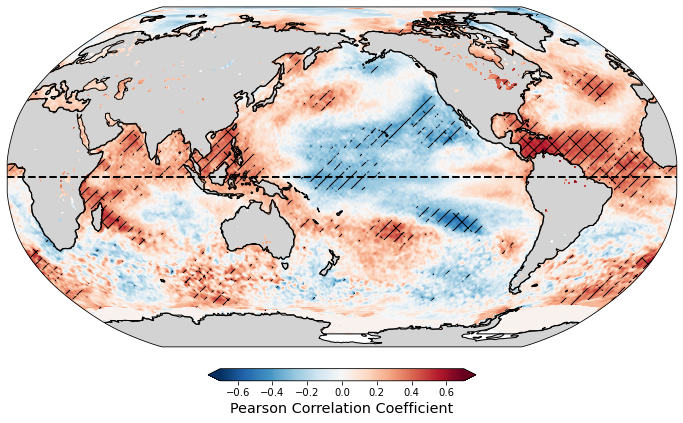

In [32]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot correlation using pcolormesh (RASTERIZE THIS)
cbar = ax.pcolormesh(
    corr.lon, corr.lat, corr,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    shading='nearest',
    vmin=-.7, vmax=.7,
    rasterized=True
)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson Correlation Coefficient')


# Hatching layers (RASTERIZE THESE TOO)
sig_mask_005 = pval < 0.05
h1 = ax.contourf(
    corr.lon, corr.lat, sig_mask_005,
    levels=[0.5, 1.5],
    hatches=['//'], colors='none',
    transform=ccrs.PlateCarree(),
)
for col in h1.collections:
    col.set_rasterized(True)

sig_mask_001 = pval < 0.01
h2 = ax.contourf(
    corr.lon, corr.lat, sig_mask_001,
    levels=[0.5, 1.5],
    hatches=['\\'], colors='none',
    transform=ccrs.PlateCarree(),
)
for col in h2.collections:
    col.set_rasterized(True)
# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()
#fig.savefig("output/Fig4c_small.svg", bbox_inches="tight", dpi=300)


0.6114378510895484


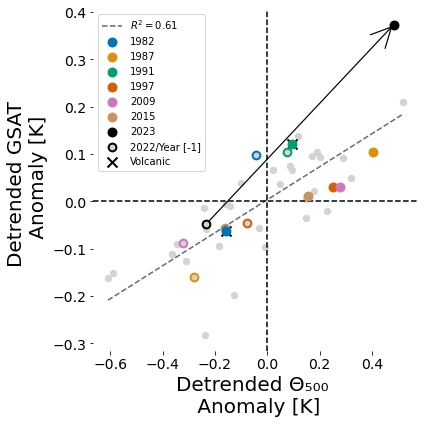

In [33]:
highlight_years = [1982, 1987, 1991, 1997, 2009, 2015]
volcanic_years = [1982, 1991]

fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=t500_aso.det,
    y=t2m_aso.t2m_detrended,
    x_label='Detrended Θ₅₀₀ \n Anomaly [K]',
    y_label = 'Detrended GSAT \n Anomaly [K]',
    years=t500_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()
fig.savefig('output/Fig4d.svg', dpi = 600, bbox_inches='tight')



# Residuals

In [39]:
#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst_full = decode_time(fp).sel(lat = slice(90,-90), time = slice('1979', '2023'))

sst_full_aso = sst_full.where(sst_full.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [40]:
from scipy.stats import pearsonr

# Assuming residuals and sst_full_aso.sst are already defined
def calc_corr_and_pval(residuals, sst, dim='year'):
    def corr_and_pval(x, y):
        mask = ~np.isnan(x) & ~np.isnan(y)  # Handle NaNs
        if mask.sum() < 2:  # Not enough data points
            return np.nan, np.nan
        r, p = pearsonr(x[mask], y[mask])
        return r, p
    
    return xr.apply_ufunc(
        corr_and_pval, 
        residuals, 
        sst,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

# Calculate correlation and p-values
corr, pval = calc_corr_and_pval(residuals, sst_full_aso.sst)

In [37]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-90,90))
ocean_mask = masks.seamask # mask for all contintnets

/tmp/ipykernel_2663040/1211869309.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


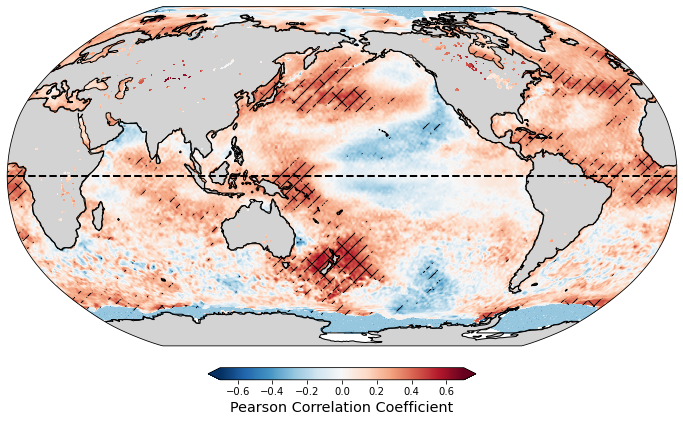

KeyboardInterrupt: 

In [38]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot correlation using pcolormesh
cbar = ax.pcolormesh(corr.lon, corr.lat, corr, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin=-.7, vmax=.7)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson Correlation Coefficient')

# Add hatching for p < 0.05
sig_mask_005 = pval < 0.05
ax.contourf(corr.lon, corr.lat, sig_mask_005, levels=[0.5, 1.5],
            hatches=['//'], colors='none', transform=ccrs.PlateCarree())

# Add hatching for p < 0.01
sig_mask_001 = pval < 0.01
ax.contourf(corr.lon, corr.lat, sig_mask_001, levels=[0.5, 1.5],
            hatches=['\\'], colors='none', transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()
fig.savefig('output/Fig4e.svg', bbox_inches='tight')



/tmp/ipykernel_2820925/276234003.py:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


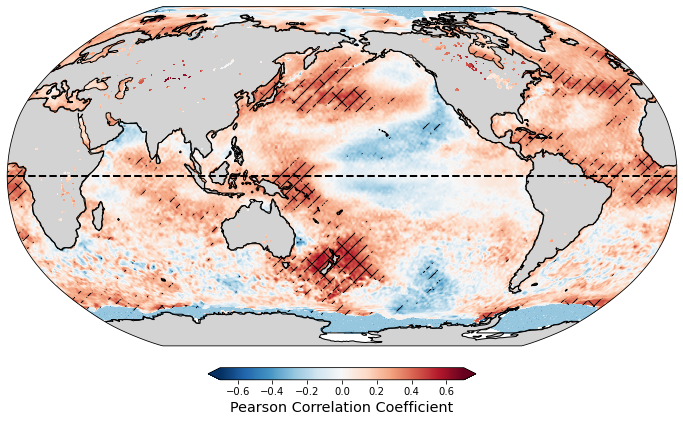

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot correlation using pcolormesh (RASTERIZE THIS)
cbar = ax.pcolormesh(
    corr.lon, corr.lat, corr,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    shading='auto',
    vmin=-.7, vmax=.7,
    rasterized=True
)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson Correlation Coefficient')


# Hatching layers (RASTERIZE THESE TOO)
sig_mask_005 = pval < 0.05
h1 = ax.contourf(
    corr.lon, corr.lat, sig_mask_005,
    levels=[0.5, 1.5],
    hatches=['//'], colors='none',
    transform=ccrs.PlateCarree(),
)
for col in h1.collections:
    col.set_rasterized(True)

sig_mask_001 = pval < 0.01
h2 = ax.contourf(
    corr.lon, corr.lat, sig_mask_001,
    levels=[0.5, 1.5],
    hatches=['\\'], colors='none',
    transform=ccrs.PlateCarree(),
)
for col in h2.collections:
    col.set_rasterized(True)
# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()
fig.savefig("output/Fig4e_small.svg", bbox_inches="tight", dpi=300)
